In [1]:
# To compare the performance of Sigmoid, Tanh, and ReLU activation functions
# by training an Artificial Neural Network on the Heart Disease dataset.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [2]:
data = pd.read_csv("heart.csv")
print(data.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [3]:
X = data.drop("target", axis=1)
y = data["target"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Feature scaling makes all features have a similar scale so that each contributes fairly to the model.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Activation Function : logistic
Accuracy : 85.25 %


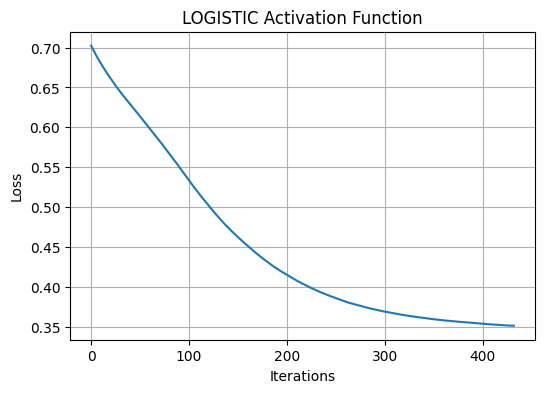

C:\Users\omkar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



Activation Function : tanh
Accuracy : 85.25 %


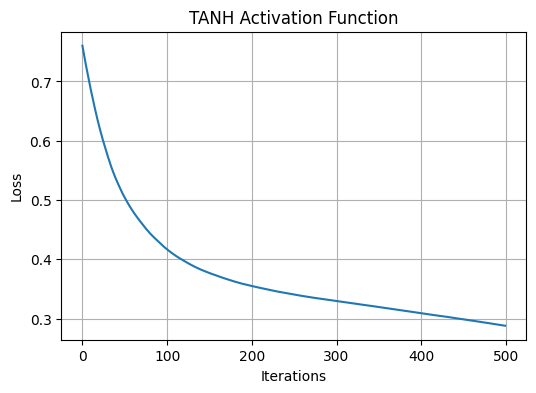


Activation Function : relu
Accuracy : 83.61 %


C:\Users\omkar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


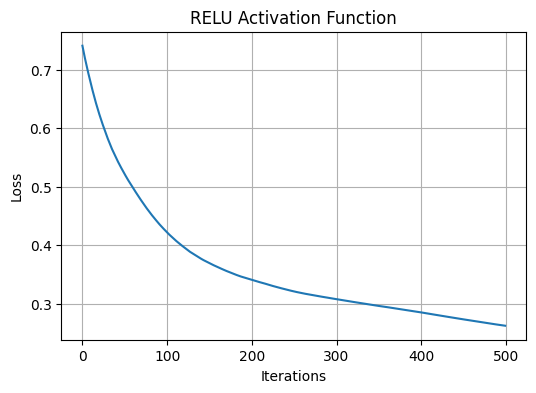

In [6]:
# logistic in sklearn means sigmoidal
functions = ["logistic", "tanh", "relu"]

for act in functions:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        max_iter=500,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    print("\nActivation Function :", act)
    print("Accuracy :", round(accuracy * 100, 2), "%")

    plt.figure(figsize=(6, 4))
    plt.plot(model.loss_curve_)
    plt.title(act.upper() + " Activation Function")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()